# A VLE for the Open University

In [1]:
import sys

print("My python version:")
print(sys.version)

My python version:
3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


This section imports all the essential libraries and tools for data manipulation, visualization, hypothesis testing, and machine learning.

In [2]:
# Import essential libraries for data manipulation and numerical operations
import numpy as np  
import pandas as pd  

# Import libraries for data visualization
import matplotlib.pyplot as plt  
import seaborn as sns 

# Statistical analysis and hypothesis testing
from scipy.stats import ttest_ind 
import statsmodels.api as sm

# Import libraries for machine learning
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 

# Import performance evaluation metrics for regression models
from sklearn.metrics import mean_absolute_error, r2_score  

# Suppress warnings to ensure cleaner output
import warnings
warnings.filterwarnings("ignore")

# Data Collection

This function, `read_data`, takes a filename (`fname`) as input and returns a DataFrame by reading the CSV file.

In [3]:
# Reads a CSV file into a DataFrame
def read_data(fname): 
    return pd.read_csv(fname)

In [4]:
# Define the file names for the CSV files containing data
fname1 = 'courses.csv'  # File containing course data
fname2 = 'assessments.csv'  # File containing assessment data
fname3 = 'vle.csv'  # File containing VLE data
fname4 = 'studentinfo.csv'  # File containing student information
fname5 = 'studentregistration.csv'  # File containing student registration details
fname6 = 'studentAssessment.csv'  # File containing student assessment records
fname7 = 'studentVle.csv'  # File containing student VLE (Virtual Learning Environment) data

# Read all the CSV files into corresponding dataframes
courses_data = read_data(fname1)  
assessments_data = read_data(fname2) 
vle_data = read_data(fname3) 
student_data = read_data(fname4)
student_registration_data = read_data(fname5) 
student_assessments_data = read_data(fname6)
student_vle_data = read_data(fname7)  

## Data Understanding

The below code snippets provide an initial overview of all the datasets by:

- Displaying the data to understand its structure and content.
- Showing the dataset's structure, including column names, data types, and missing values.
- Generating summary statistics for numerical columns and categorical columns.

### 1. Course_data

In [5]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(courses_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(courses_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(courses_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(courses_data.describe(include = [object]))

Dataset Overview:


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   code_module                 22 non-null     object
 1   code_presentation           22 non-null     object
 2   module_presentation_length  22 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 660.0+ bytes


None


Summary statistics for numerical columns:


,module_presentation_length
count,22.000000
mean,255.545455
std,13.654677
min,234.000000
25%,241.000000
50%,261.500000
75%,268.000000
max,269.000000


Summary statistics for categoricalcal columns:


,code_module,code_presentation
count,22,22
unique,7,4
top,BBB,2014J
freq,4,7


- The dataset offers insights into the organization and timing of academic modules.
- It contains **22 records** across **3 columns**, with **no missing values**.
- It includes 7 distinct modules and 4 presentation cycles.
- The **module durations** range from 234 to 269 days, with an **average length** of approximately **256 days**.

### 2. assessments_data

In [6]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(assessments_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(assessments_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(assessments_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(assessments_data.describe(include = [object]))

Dataset Overview:


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               206 non-null    object 
 5   weight             206 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 9.8+ KB


None


Summary statistics for numerical columns:


,id_assessment,weight
count,206.000000,206.000000
mean,26473.975728,20.873786
std,10098.625521,30.384224
min,1752.000000,0.000000
25%,15023.250000,0.000000
50%,25364.500000,12.500000
75%,34891.750000,24.250000
max,40088.000000,100.000000


Summary statistics for categoricalcal columns:


,code_module,code_presentation,assessment_type,date
count,206,206,206,206
unique,7,4,3,75
top,FFF,2014J,TMA,222
freq,52,57,106,15


- The dataset provides data about assessments within academic modules.
- It consists of **206 records and 6 columns**, with **no missing values**.
- The dataset spans across 7 unique modules and 4 presentation cycles, with assessments categorized into 3 types.
- Assessment weights vary, with an **average of 20.87**, ranging from 0 to 100.
- The dataset includes assessments over 75 unique dates, with the most frequent assessment occurring on date 222.

### 3. student_assessments_data

In [7]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(student_assessments_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(student_assessments_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(student_assessments_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(student_assessments_data.describe(include = [object]))

Dataset Overview:


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id_assessment   173912 non-null  int64 
 1   id_student      173912 non-null  int64 
 2   date_submitted  173912 non-null  int64 
 3   is_banked       173912 non-null  int64 
 4   score           173912 non-null  object
dtypes: int64(4), object(1)
memory usage: 6.6+ MB


None


Summary statistics for numerical columns:


,id_assessment,id_student,date_submitted,is_banked
count,173912.000000,1.739120e+05,173912.000000,173912.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977
std,8829.784254,5.523952e+05,71.484148,0.104194
min,1752.000000,6.516000e+03,-11.000000,0.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000
max,37443.000000,2.698588e+06,608.000000,1.000000


Summary statistics for categoricalcal columns:


,score
count,173912
unique,102
top,100
freq,18813


- The dataset provides detailed information on student assessments, with **173,912 records across 5 columns** and **no missing values**.
- Mean submission date is approximately **116 days**.
- Most records indicate scores that are not banked (as shown by the low proportion of is_banked values of 1).

### 4. student_data

In [8]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(student_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(student_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(student_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(student_data.describe(include = [object]))

Dataset Overview:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              32593 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


None


Summary statistics for numerical columns:


,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


Summary statistics for categoricalcal columns:


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,disability,final_result
count,32593,32593,32593,32593,32593,32593,32593,32593,32593
unique,7,4,2,13,5,11,3,2,4
top,BBB,2014J,M,Scotland,A Level or Equivalent,20-30%,0-35,N,Pass
freq,7909,11260,17875,3446,14045,3654,22944,29429,12361


- The dataset provides information about students' characteristics and their academic outcomes.
- It contains **32,593 records and 12 columns**, with **no missing values**.
- Key student details like region, highest education, disability status, and age band are captured, along with their academic history (e.g., number of previous attempts, studied credits).
- The final results are categorized into 4 outcomes, with the majority of students passing the course.
- The **average number of studied credits** is approximately **79.76**, and most students have no previous attempts.

### 5. student_registration_data

In [9]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(student_registration_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(student_registration_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(student_registration_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(student_registration_data.describe(include = [object]))

Dataset Overview:


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159,?
1,AAA,2013J,28400,-53,?
2,AAA,2013J,30268,-92,12
3,AAA,2013J,31604,-52,?
4,AAA,2013J,32885,-176,?


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   code_module          32593 non-null  object
 1   code_presentation    32593 non-null  object
 2   id_student           32593 non-null  int64 
 3   date_registration    32593 non-null  object
 4   date_unregistration  32593 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.2+ MB


None


Summary statistics for numerical columns:


,id_student
count,3.259300e+04
mean,7.066877e+05
std,5.491673e+05
min,3.733000e+03
25%,5.085730e+05
50%,5.903100e+05
75%,6.444530e+05
max,2.716795e+06


Summary statistics for categoricalcal columns:


,code_module,code_presentation,date_registration,date_unregistration
count,32593,32593,32593,32593
unique,7,4,333,417
top,BBB,2014J,-22,?
freq,7909,11260,1034,22521


- The dataset provides insights into students' characteristics and academic history.
- It contains **32,593 records and 5 columns**, with **no missing values**.
- The most common module is BBB, and the most frequent presentation cycle is 2014J.
- There are **formatting issues** with date_registration showing **"-22"** and a large number of date_unregistration marked as **"?"**.

### 6. student_vle_data

In [10]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(student_vle_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(student_vle_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(student_vle_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(student_vle_data.describe(include = [object]))

Dataset Overview:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   code_module        object
 1   code_presentation  object
 2   id_student         int64 
 3   id_site            int64 
 4   date               int64 
 5   sum_click          int64 
dtypes: int64(4), object(2)
memory usage: 487.8+ MB


None


Summary statistics for numerical columns:


,id_student,id_site,date,sum_click
count,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
mean,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00
max,2.698588e+06,1.049562e+06,2.690000e+02,6.977000e+03


Summary statistics for categoricalcal columns:


,code_module,code_presentation
count,10655280,10655280
unique,7,4
top,FFF,2014J
freq,4014499,3619452


- The dataset provides detailed information about student activity on the VLE.
- It contains **10,655,280 records and 6 columns**, with **no missing values**.
- The most frequent module is 'FFF' and the most common presentation cycle is '2014J'.
- The **average number of clicks** is approximately **3.72**, with a **maximum of 6,977 clicks**.
- The date field includes both negative and large positive values, suggesting possible **data formatting issues**.

### 7. vle_data

In [11]:
# Display the first 5 rows to preview the dataset's structure and content
print("Dataset Overview:")
display(vle_data.head(5))

# Display dataset structure, including column data types and missing values
print("Dataset Structure:\n")
display(vle_data.info())

# Generate summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(vle_data.describe())

# Generate summary statistics for categorical columns
print("Summary statistics for categoricalcal columns:")
display(vle_data.describe(include = [object]))

Dataset Overview:


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?


Dataset Structure:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_site            6364 non-null   int64 
 1   code_module        6364 non-null   object
 2   code_presentation  6364 non-null   object
 3   activity_type      6364 non-null   object
 4   week_from          6364 non-null   object
 5   week_to            6364 non-null   object
dtypes: int64(1), object(5)
memory usage: 298.4+ KB


None


Summary statistics for numerical columns:


,id_site
count,6.364000e+03
mean,7.260991e+05
std,1.283151e+05
min,5.267210e+05
25%,6.615928e+05
50%,7.300965e+05
75%,8.140162e+05
max,1.077905e+06


Summary statistics for categoricalcal columns:


,code_module,code_presentation,activity_type,week_from,week_to
count,6364,6364,6364,6364,6364
unique,7,4,20,31,31
top,FFF,2013J,resource,?,?
freq,1967,1772,2660,5243,5243


- The dataset contains information about various academic activities, detailing student interactions with VLE.
- It includes **6,364 records and 6 columns**, with **no missing values**.
- The most frequent activity type is 'resource', and the majority of the data points have undefined week ranges ('?').

# Data Wrangling & Cleaning

## 1. Renaming Column Names
This section standardizes the column names across multiple datasets to ensure consistency, making it easier to work with them during analysis and merging.

In [12]:
# 1. Renaming 'courses_data' columns
# Columns to be renamed
new_column_names = {'code_module': 'module_code', 
                    'code_presentation': 'presentation_code',
                    'module_presentation_length': 'module_length_days'}
# Rename columns
courses_data.rename(columns = new_column_names, inplace = True)

# 2. Renaming 'assessments_data' columns
# Columns to be renamed
new_column_names = {'code_module': 'module_code',
                    'code_presentation': 'presentation_code',
                    'id_assessment': 'assessment_id',
                    'assessment_type': 'assessment_type',
                    'date': 'assessment_date',
                    'weight': 'assessment_weight_marks'}
# Rename columns
assessments_data.rename(columns = new_column_names, inplace = True)

# 3. Renaming 'student_assessments_data' columns
# Columns to be renamed
new_column_names = {'id_assessment': 'assessment_id',
                    'id_student': 'student_id',
                    'date_submitted': 'submission_date',
                    'is_banked': 'is_assessment_banked',
                    'score': 'assessment_score'}
# Rename columns
student_assessments_data.rename(columns = new_column_names, inplace = True)

# 4. Renaming 'student_data' columns
# Columns to be renamed
new_column_names = {'code_module': 'module_code',
                    'code_presentation': 'presentation_code',
                    'id_student': 'student_id',
                    'gender': 'student_gender',
                    'region': 'student_region',
                    'highest_education': 'highest_education_level',
                    'imd_band': 'imd_band_score',
                    'age_band': 'age_band_years',
                    'num_of_prev_attempts': 'previous_attempts_count',
                    'studied_credits': 'studied_credits_number',
                    'disability': 'has_disability',
                    'final_result': 'final_result_status'}
# Rename columns
student_data.rename(columns = new_column_names, inplace = True)

# 5. Renaming 'student_registration_data' columns
# Columns to be renamed
new_column_names = {'code_module': 'module_code',
                    'code_presentation': 'presentation_code',
                    'id_student': 'student_id',
                    'date_registration': 'registration_date',
                    'date_unregistration': 'unregistration_date'}
# Rename columns
student_registration_data.rename(columns = new_column_names, inplace = True)

# 6. Renaming 'student_vle' columns
# Columns to be renamed
new_column_names = {'code_module': 'module_code',
                    'code_presentation': 'presentation_code',
                    'id_student': 'student_id',
                    'id_site': 'vle_site_id',
                    'date': 'interaction_date',
                    'sum_click': 'clicks_count'}
# Rename columns
student_vle_data.rename(columns = new_column_names, inplace = True)

# 7. Renaming 'vle_data' columns
# Columns to be renamed
new_column_names = { 'id_site': 'vle_site_id',
                    'code_module': 'module_code',
                    'code_presentation': 'presentation_code',
                    'week_from': 'week_from_number',
                    'week_to': 'week_to_number'}
# Rename columns
vle_data.rename(columns = new_column_names, inplace = True)

## 2. Handling Missing / Invalid Data
This section addresses the removal of rows containing invalid or missing data, represented by the **"?"** symbol, from various datasets. This ensures that the analysis remains based on accurate and complete data.

In [13]:
# List of datasets to check for duplicates
datasets = {'courses': courses_data,
            'assessments': assessments_data,
            'student_assessments': student_assessments_data,
            'student_info': student_data,
            'student_registration': student_registration_data,
            'student_vle': student_vle_data,
            'vle': vle_data}
#null values
for name, dataset in datasets.items():
    if dataset.isnull().values.any():  # Check if there are any null values
        # Count null values in each column
        null_counts = dataset.isnull().sum()
        
        # Display the columns with null values and their counts
        print(f"The {name} DataFrame contains the following null values:\n{null_counts[null_counts > 0]}")

No null values as per the previous section "Data Understanding" and reconfirmed here as well.

In [14]:
# 1. Remove rows where 'assessment_score' is '?'
rows_with_invalid_score = student_assessments_data[student_assessments_data['assessment_score'] == '?']
# Exclude rows with '?' in 'assessment_score'
student_assessments_data = student_assessments_data[student_assessments_data['assessment_score'] != '?']
print(f"{len(rows_with_invalid_score)} rows with '?' removed from assessment_score.")

# 2. Remove rows where 'week_from_number' is '?'
rows_with_invalid_week = vle_data[vle_data['week_from_number'] == '?']
# Exclude rows with '?' in 'week_from_number'
vle_data = vle_data[vle_data['week_from_number'] != '?']
print(f"{len(rows_with_invalid_week)} rows with '?' removed from week_from_number.")

# 3. Remove rows where 'registration_date' is '?'
rows_with_invalid_registration = student_registration_data[student_registration_data['registration_date'] == '?']
# Exclude rows with '?' in 'registration_date'
student_registration_data = student_registration_data[student_registration_data['registration_date'] != '?']
print(f"{len(rows_with_invalid_registration)} rows with '?' removed from registration_date.")

# 4. Remove rows where 'imd_band_score' is '?'
rows_with_invalid_imd_band_score = student_data[student_data['imd_band_score'] == '?']
# Keep only rows with '?' in 'imd_band_score'
student_data = student_data[student_data['imd_band_score'] != '?']
print(f"{len(rows_with_invalid_imd_band_score)}  rows with '?' removed from imd_band_score.")

# 5. Remove rows where 'assessment_date' is '?'
rows_with_invalid_assessment_date = assessments_data[assessments_data['assessment_date'] == '?']
# Exclude rows with '?' in 'assessment_score'
assessments_data = assessments_data[assessments_data['assessment_date'] != '?']
print(f"{len(rows_with_invalid_assessment_date)} rows with '?' removed from assessment_date.")

173 rows with '?' removed from assessment_score.
5243 rows with '?' removed from week_from_number.
45 rows with '?' removed from registration_date.
1111  rows with '?' removed from imd_band_score.
11 rows with '?' removed from assessment_date.


## 3. Data Filteration
This line filters out students who have a `"Withdrawn"` status in the final_result_status column, retaining only the students who have not withdrawn from the course. This is important to focus on active students for further analysis.

Additionally, Only students who have not unregistered are retained in the dataset. It keeps rows where the unregistration_date is missing, indicating that these students are still registered.

In [15]:
# Exclude rows where 'final_result_status' is 'Withdrawn'
student_data = student_data[student_data['final_result_status'] != 'Withdrawn']

# Exclude rows where 'unregistration_date' is not '?'
rows_with_unregistration_date = student_registration_data[student_registration_data['unregistration_date'] != '?']
# Keep only rows with '?' in 'unregistration_date'
student_registration_data = student_registration_data[student_registration_data['unregistration_date'] == '?']
print(f"{len(rows_with_unregistration_date)} rows with registered students retained.")

10033 rows with registered students retained.


## 4. Typecasting

This section ensures that the data types of certain columns are properly converted to ensure consistency and correctness for further analysis. Conversions include changing 'Id's to strings, 'assessment_score' and 'week_from_number' to integers, and dates to integer type for easier processing.

Converting ID columns to strings ensures data integrity by preserving unique identifiers, including any leading zeros or special characters. It prevents unintended numerical operations and improves efficiency during data manipulation, especially for joins and lookups, where IDs serve as references rather than numeric values.

In [16]:
# 1. Convert 'assessment_id', 'student_id', and 'vle_site_id' to string type for consistency
assessments_data['assessment_id'] = assessments_data['assessment_id'].astype(str)
student_assessments_data['assessment_id'] = student_assessments_data['assessment_id'].astype(str)
student_assessments_data['student_id'] = student_assessments_data['student_id'].astype(str)
student_data['student_id'] = student_data['student_id'].astype(str)
student_registration_data['student_id'] = student_registration_data['student_id'].astype(str)
student_vle_data['student_id'] = student_vle_data['student_id'].astype(str)
student_vle_data['vle_site_id'] = student_vle_data['vle_site_id'].astype(str)
vle_data['vle_site_id'] = vle_data['vle_site_id'].astype(str)

# 2. Convert 'assessment_score' from string to integer
student_assessments_data['assessment_score'] = student_assessments_data['assessment_score'].astype(int)

# 3. Convert 'week_from_number' from string to integer
vle_data['week_from_number'] = vle_data['week_from_number'].astype(int)

# 4. Convert dates (as strings) to integers for proper date processing
student_registration_data['registration_date'] = student_registration_data['registration_date'].astype(int)
student_assessments_data['submission_date'] = student_assessments_data['submission_date'].astype(int)
student_vle_data['interaction_date'] = student_vle_data['interaction_date'].astype(int)

## 5. Modifying Date Columns

This section converts the day columns (stored as integers) to actual dates by adding them as days to the reference date of `'2023-01-01'`. The pd.to_timedelta function is used to perform this conversion, ensuring the dates are accurate and manageable for analysis.

In [17]:
# Define reference date (2023-01-01)
reference_date = pd.Timestamp('2023-01-01')

# Convert day columns to actual dates 
student_registration_data['registration_date'] = reference_date + pd.to_timedelta(student_registration_data['registration_date'],  errors = 'coerce')
student_assessments_data['submission_date'] = reference_date + pd.to_timedelta(student_assessments_data['submission_date'], errors = 'coerce')
student_vle_data['interaction_date'] = reference_date + pd.to_timedelta(student_vle_data['interaction_date'], errors = 'coerce')

## 6. Handling Duplicate Rows

This block of code checks each dataset in the datasets dictionary for duplicate rows. If any duplicates are found, it calculates the total number of duplicates and removes them, keeping only the first occurrence.

**787170 duplicate rows** have been removed from student_vle data

In [18]:
# List of datasets to check for duplicates
datasets = {'courses': courses_data,
            'assessments': assessments_data,
            'student_assessments': student_assessments_data,
            'student_info': student_data,
            'student_registration': student_registration_data,
            'student_vle': student_vle_data,
            'vle': vle_data}

# Loop through datasets and handle duplicates
for name, dataset in datasets.items():
    if  dataset.duplicated().any(): # Check if there are any duplicates
        # Count duplicates
        duplicate_rows = dataset.duplicated().sum()
        
        # Remove duplicates, keeping the first occurrence
        dataset.drop_duplicates(keep = 'first', inplace = True)
        # Display the number of duplicates removed
        print(f"The {name} DataFrame contains {duplicate_rows} duplicates.") 

The student_vle DataFrame contains 787170 duplicates.


# Merging All the Cleaned Datasets
This script combines multiple datasets (assessments, courses, student assessments, registration, and VLE interactions) to create a comprehensive dataset. Standardized scores are calculated, and VLE clicks are aggregated for analysis.

To standardize assessment scores, created a new feature, "weighted_score," by multiplying the raw score by its corresponding weight and dividing by 100. This ensures assessments with varying weights are treated equally. Additionally, aggregated total clicks per student per module by summing "clicks_count," capturing overall student engagement with the VLE.

In [19]:
# Merge assessments with course details using module and presentation codes
assessments_courses = pd.merge(assessments_data, courses_data, on = ['module_code', 'presentation_code'], how = 'inner')

# Merge student assessments with the combined assessments and courses data
student_assessments_merged = pd.merge(student_assessments_data, assessments_courses, on = 'assessment_id', how = 'inner')

# Standardize the assessment scores by incorporating weight
student_assessments_merged['weighted_score'] = (student_assessments_merged['assessment_score'] * student_assessments_merged['assessment_weight_marks']) / 100

# Merge with student demographic and course information
student_data_merged = pd.merge(student_assessments_merged, student_data, on = ['student_id', 'module_code', 'presentation_code'], how = 'inner')

# Combine with student registration details
student_registration_merged = pd.merge(student_data_merged, student_registration_data, on = ['student_id', 'module_code', 'presentation_code'], how = 'inner')

# Merge student VLE interaction data with the VLE dataset
student_vle_merged = pd.merge(student_vle_data, vle_data, on = ['vle_site_id', 'module_code', 'presentation_code'], how = 'inner')

# Summarize the total clicks per student for each module presentation
aggregated_clicks = student_vle_merged.groupby(['module_code', 'presentation_code', 'student_id'])['clicks_count'].sum().reset_index()

# Merge the aggregated clicks data with the registration and assessment data
student_combined_data = pd.merge(student_registration_merged, aggregated_clicks, on = ['student_id', 'module_code', 'presentation_code'], how = 'inner')

# Display the shape of the final dataset
print("Merged dataset shape:", student_combined_data.shape)

Merged dataset shape: (115839, 24)


This code classifies student VLE interactions into two categories: **'high_interaction'** and **'low_interaction'** based on whether the number of clicks is above or below the median value of the `clicks_count` column

In [20]:
# Create 'interaction_level' based on whether clicks count is above or below the median
student_combined_data['interaction_level'] = np.where(student_combined_data['clicks_count'] >= 
                                                      student_combined_data['clicks_count'].median(), 
                                                      'high_interaction', 'low_interaction')

# Exploratory Data Analysis (EDA) 

## 1. Box Plot Visualization for Numeric Data
This code iterates through each dataset in the datasets dictionary. For each dataset, it filters only the numeric columns. Box plots to visualize the distribution of the numeric data and to check for **Outliers**

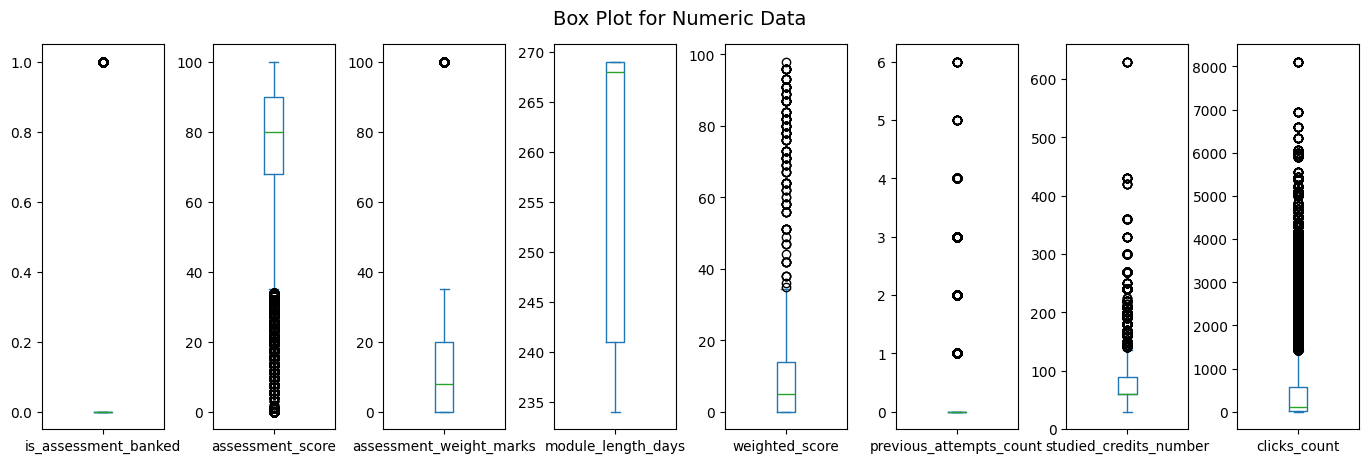

In [21]:
# Filter only numeric columns
numeric_data = student_combined_data.select_dtypes(include = ['number'])

#Creat box plot
numeric_data.plot(kind = 'box', subplots = True, sharey = False, figsize = (17, 5))
plt.subplots_adjust(wspace = 0.4)

# Set a centered title
plt.suptitle('Box Plot for Numeric Data', fontsize = 14, y = 0.95) 

# Adjust x-tick label size
for ax in plt.gcf().get_axes():
    ax.tick_params(axis = 'x', labelsize = 9.8)

#display plot
plt.show()

- Outliers like (100) in `assessment_weight_marks` are valid because they accurately represent `assessment_type` - Exam with full weight. Therefore, they are retained in the dataset.

- Outliers in `student_id` typically don't affect the analysis since it is not a numerical feature but a categorical identifier. Therefore, they are retained in the dataset.

- `is_assessment banked` is binary data.

- `assessment_score`: It's not uncommon to have a range of scores, including some very low scores. These low scores could represent students who faced challenges, had difficulty with the material, or had other extenuating circumstances. Removing these data points might introduce bias and distort the true distribution of student performance.

- `Studied Credits Number`: Outliers may indicate students with extensive prior learning or multiple course enrollments.

- `Previous Attempts Count`: Outliers may reflect students who faced challenges or took longer to complete the module.

- `Clicks Count`: Outliers could represent students with different learning styles, either engaging in intensive sessions or frequent short interactions.

## 2. Relationships Between Demographic Features and Final Result

This code uses countplot from Seaborn to visualize the relationship between demographic features (`student_gender` and `age_band_years`) and the `final_result_status`. The plots display how the final result status varies across different genders and age bands

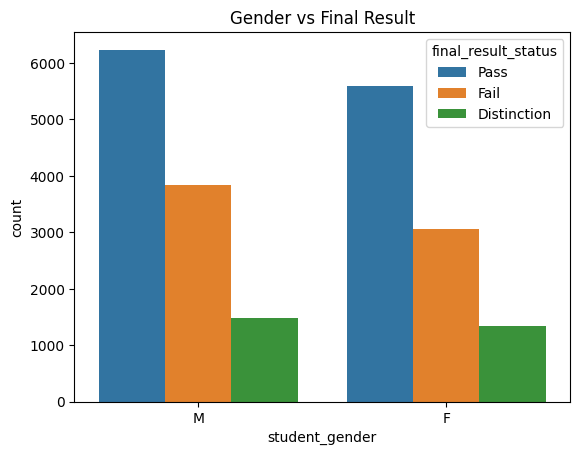

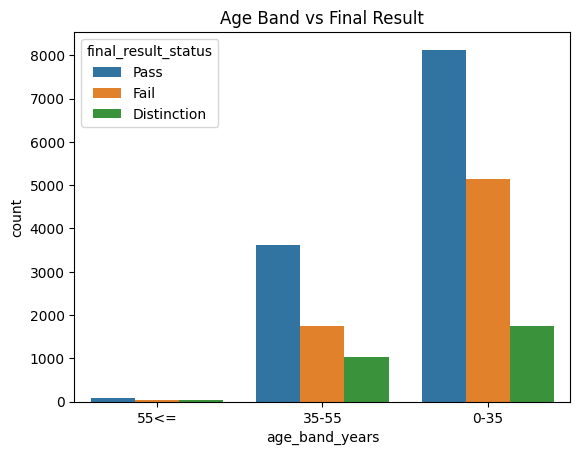

In [22]:
# Gender vs Final Result
sns.countplot(data = student_data, x = 'student_gender', hue = 'final_result_status')
plt.title('Gender vs Final Result')
plt.show()

# Age band vs Final Result
sns.countplot(data = student_data, x = 'age_band_years', hue = 'final_result_status')
plt.title('Age Band vs Final Result')
plt.show()

## 3. Visualizing the Top 5 Modules Chosen by Students
This section identifies and visualizes the top 5 modules most frequently selected by students. The bar chart provides a clear representation of the number of students enrolled in each of the top modules, helping to understand module popularity.

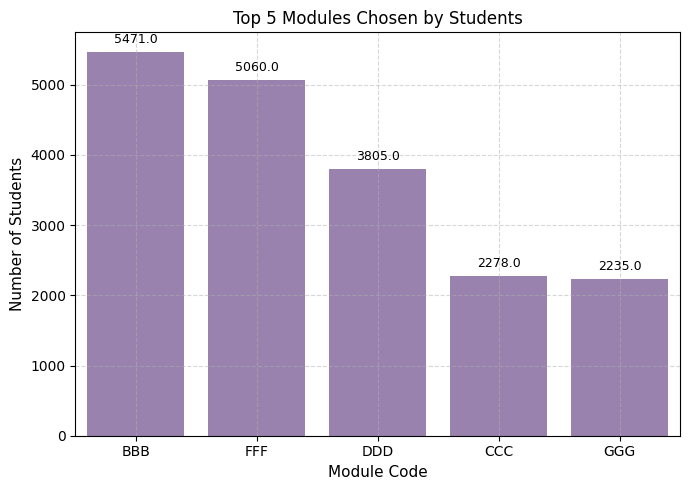

In [23]:
# Get the top 5 modules chosen by students
top_5_modules_chosen = student_data['module_code'].value_counts().head(5)

# Create the plot
plt.figure(figsize = (7, 5))  # Set figure size

# Create a bar plot
ax = sns.barplot(x = top_5_modules_chosen.index, y = top_5_modules_chosen.values, color = "#9b7bb5")

# Titles and labels
plt.title("Top 5 Modules Chosen by Students", fontsize = 12)
plt.xlabel("Module Code", fontsize = 11)
plt.ylabel("Number of Students", fontsize = 11)

# Gridlines for better readability
plt.grid(visible = True, linestyle = '--', alpha = 0.5)

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', fontsize = 9, color = 'black', xytext = (0, 9), 
                textcoords = 'offset points')

# Adjust tick sizes for readability
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Show the plot
plt.tight_layout()
plt.show()

## 4. Visualizing the Top 5 modules with the Highest Average Score
This snippet merges student assessment data with module details to calculate and visualize the top 5 modules with the highest average assessment scores.

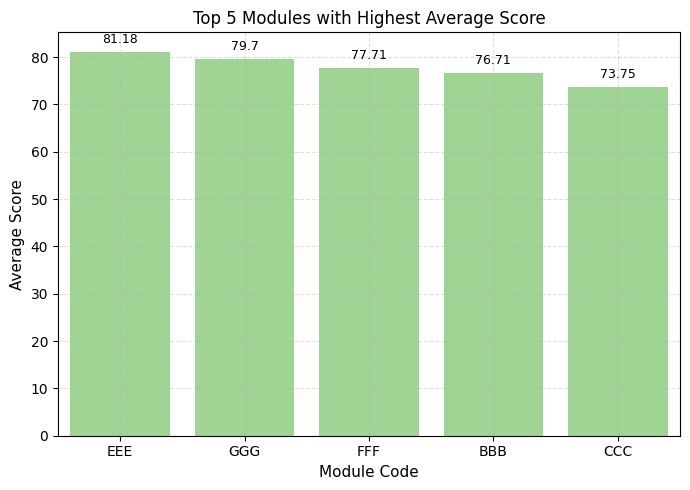

In [24]:
# Merge student_assessments with assessments to get 'module_code'
merged_assessment_data = pd.merge(student_assessments_data, assessments_data, on = 'assessment_id')

# Calculate the average assessment score for each module
top_5_modules_highest_avg_score = (merged_assessment_data.groupby('module_code')['assessment_score'].mean().round(2).sort_values(ascending = False).head(5))

# Initialize the plot with specified dimensions
plt.figure(figsize = (7, 5))  # Set figure size

# Generate a bar plot for the top 5 modules with the highest average scores
ax = sns.barplot(x = top_5_modules_highest_avg_score.index, y = top_5_modules_highest_avg_score.values, color = "#98df8a")

# Titles and labels
plt.title("Top 5 Modules with Highest Average Score", fontsize = 12)
plt.xlabel("Module Code", fontsize = 11)
plt.ylabel("Average Score", fontsize = 11)

# Gridlines for better readability
plt.grid(visible = True, linestyle = '--', alpha = 0.4)

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', fontsize = 9, color = 'black', xytext = (0, 9), 
                textcoords = 'offset points')

# Adjust tick sizes for readability
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Show the plot
plt.tight_layout()
plt.show()

## 5. Visualizing Top 5 Modules with the Lowest Average Score
This visualization identifies the top 5 modules with the lowest average assessment scores. Data is grouped by module codes, and average scores are calculated.

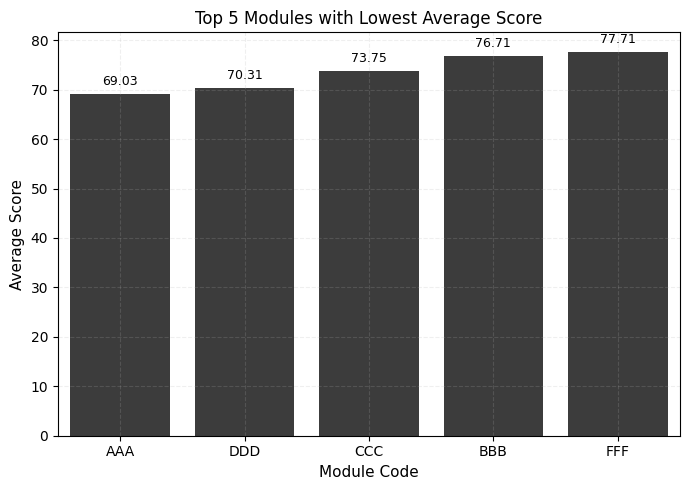

In [25]:
# Group data by 'module_code' and calculate the average assessment score for each module
top_5_modules_lowest_avg_score = merged_assessment_data.groupby('module_code')['assessment_score'].mean().round(2).sort_values(ascending = True).head(5)

# Set the figure size for the plot
plt.figure(figsize = (7, 5))  # Set figure size

# Create a bar plot for the modules with the lowest average scores
ax = sns.barplot(x = top_5_modules_lowest_avg_score.index, y = top_5_modules_lowest_avg_score.values, color = "#3c3c3c")

# Titles and labels
plt.title("Top 5 Modules with Lowest Average Score", fontsize = 12)
plt.xlabel("Module Code", fontsize = 11)
plt.ylabel("Average Score", fontsize = 11)

# Gridlines for better readability
plt.grid(visible = True, linestyle = '--', alpha = 0.2)

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', fontsize = 9, color = 'black', xytext = (0, 9), 
                textcoords = 'offset points')

# Adjust tick sizes for readability
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Show the plot
plt.tight_layout()
plt.show()

## 6. Visualizing Top 5 modules with the Most Number of Fails
This analysis identifies the top 5 modules with the highest number of failing students. The dataset is filtered to focus on students with 'Fail' status

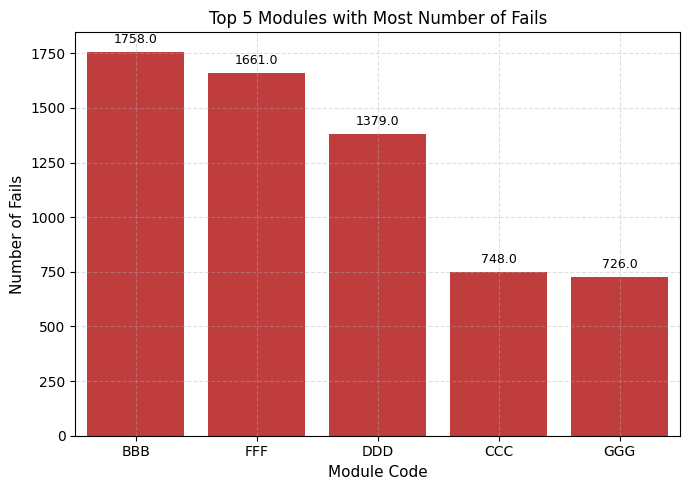

In [26]:
# Filter out students with 'Fail' status
failed_students = student_data[student_data['final_result_status'] == 'Fail']

# Count the number of failing students for each module
top_5_modules_most_fails = failed_students['module_code'].value_counts().head(5)

# Set the figure size for the plot
plt.figure(figsize = (7, 5))  # Set figure size

# Create a bar plot to display the modules with the highest number of fails
ax = sns.barplot(x = top_5_modules_most_fails.index, y = top_5_modules_most_fails.values, color = "#d62728")

# Titles and labels
plt.title("Top 5 Modules with Most Number of Fails", fontsize = 12)
plt.xlabel("Module Code", fontsize = 11)
plt.ylabel("Number of Fails", fontsize = 11)

# Gridlines for better readability
plt.grid(visible = True, linestyle = '--', alpha = 0.4)

# Add value counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha ='center', va ='center', fontsize = 9, color = 'black', xytext = (0, 9), 
                textcoords = 'offset points')

# Adjust tick sizes for readability
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

# Show the plot
plt.tight_layout()
plt.show()

## 7. Visualizing The Age Distribution of the Students
This pie chart displays the age distribution of students as a percentage. Each segment represents an age band, with the chart annotated for clarity. The distribution provides insights into the demographic composition of the dataset.

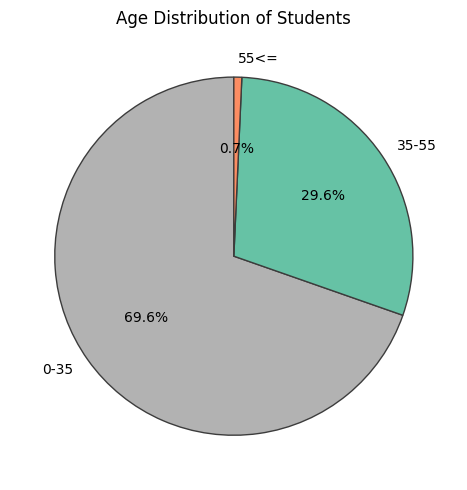

In [27]:
# Calculate percentage distribution for the 'age_band_years' column
age_band_counts = student_data['age_band_years'].value_counts(normalize = True) * 100  # Convert to percentages

# Set the figure size for the pie chart
plt.figure(figsize = (7, 5))  # Set figure size

# Define a custom color palette for better visualization
colors = ['#b2b2b2', '#66c2a5', '#fc8d62'] 

# Create a pie chart for age distribution
plt.pie(
    age_band_counts, 
    labels = age_band_counts.index, 
    autopct = '%1.1f%%', 
    startangle = 90, 
    colors = colors,
    textprops = {'fontsize': 10},
    wedgeprops = {'edgecolor': '#3c3c3c'}
)

# Add a title
plt.title("Age Distribution of Students", fontsize = 12)

# Show the plot
plt.tight_layout()
plt.show()

## 8. Visualizing Weekly Activity Patterns of Students' Interaction with the VLE
This line plot visualizes weekly activity patterns based on total student interactions with the Virtual Learning Environment (VLE). Each data point represents the aggregated number of clicks for a given week, providing insights into the peak and trough of activity over time.

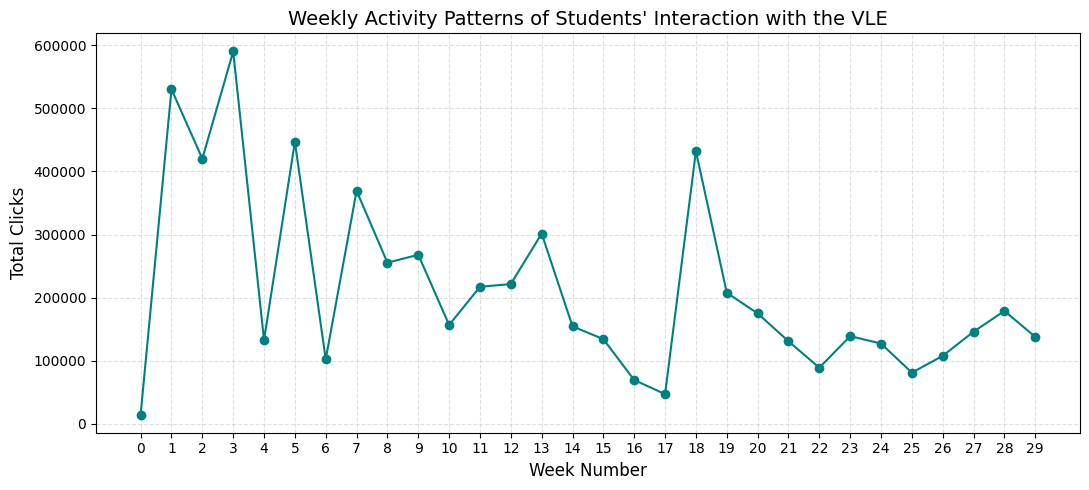

In [28]:
# Merge student_vle_data and vle_data to include week information
merged_data = student_vle_data.merge(vle_data, on = ['module_code', 'presentation_code', 'vle_site_id'], how = 'left')

# Aggregate clicks by week
weekly_activity = merged_data.groupby('week_from_number')['clicks_count'].sum().reset_index()

# Sort the data by week number (it's already sorted, but ensuring it's sorted for categorical type)
weekly_activity = weekly_activity.sort_values(by = 'week_from_number')

# Create the plot
plt.figure(figsize = (11, 5))  # Set figure size

# Line plot showing total clicks per week
plt.plot(weekly_activity['week_from_number'], weekly_activity['clicks_count'], marker = 'o', linestyle = '-', color = 'teal')


plt.title("Weekly Activity Patterns of Students' Interaction with the VLE", fontsize = 14)
plt.xlabel("Week Number", fontsize = 12)
plt.ylabel("Total Clicks", fontsize = 12)

# Gridlines for better readability
plt.grid(visible = True, linestyle = '--', alpha = 0.4)

# Adjust tick sizes for readability
plt.xticks(weekly_activity['week_from_number'], fontsize = 10)
plt.yticks(fontsize = 10)

# Show the plot
plt.tight_layout()
plt.show()

# Is the VLE improving students' grades?
# Hypothesis Testing

This code performs a  one-tailed, two-sample t-test (left tail) to compare the mean grades between two groups based on their interaction level with the VLE. It calculates the p-value and compares it with the significance level (5%) to determine if the high interaction group has significantly higher grades. The confidence interval for the mean difference is also calculated and displayed.

**Hypothesis Testing Results:**
- **Null Hypothesis (H₀)**: The mean grade of high interaction students is less than or equal to that of low interaction students.
    
- **Alternative Hypothesis (H₁)**: The mean grade of high interaction students is greater than that of low interaction students.

In [30]:
# Significance level (5%)
alpha = 0.05

# Separate weighted scores based on interaction level
high_interaction_grades = student_combined_data.loc[student_combined_data['interaction_level'] == 'high_interaction', 'weighted_score']
low_interaction_grades = student_combined_data.loc[student_combined_data['interaction_level'] == 'low_interaction', 'weighted_score']

# Perform a  one-tailed, two-sample t-test (left tail) to compare grades between high and low interaction groups
result = ttest_ind(high_interaction_grades, low_interaction_grades, nan_policy ='omit', alternative ='greater')

# Calculate the confidence interval for the result
ci = result.confidence_interval(confidence_level = 1 - alpha)

# Compare the p-value with the significance level (alpha) to draw conclusions
if result.pvalue < alpha:
    print(f"Reject the null hypothesis at the {alpha*100}% significance level")
else:
    print(f"Fail to reject the null hypothesis at the {alpha*100}% significance level")
       
# Print the T-test result details
print(f"\nT-statistic = {result.statistic:.2f}, P-value = {result.pvalue:.2f}\n")

# Print the confidence interval for the result
print(ci)

Reject the null hypothesis at the 5.0% significance level

T-statistic = 40.65, P-value = 0.00

ConfidenceInterval(low=1.9683634880135235, high=inf)


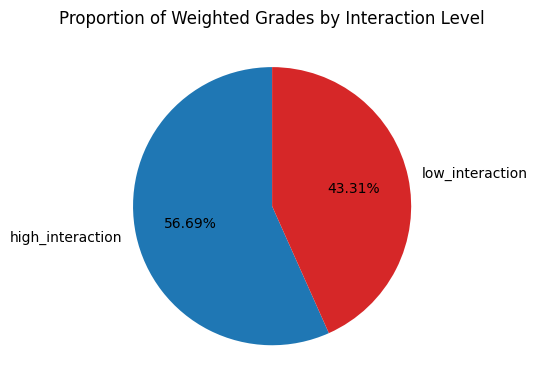

In [31]:
import matplotlib.pyplot as plt

# Calculate the mean weighted scores for each interaction level
interaction_means = student_combined_data.groupby('interaction_level')['weighted_score'].mean()

# Define labels and data for the pie chart
labels = interaction_means.index
values = interaction_means.values

# Set the figure size for the pie chart
plt.figure(figsize = (7, 4))

# Create a pie chart
plt.pie(
    values,
    labels = labels,
    autopct='%1.2f%%',
    startangle = 90,
    colors = ["#1f77b4", "#d62728"],
    textprops = {'fontsize': 10}
)

# Add a title
plt.title("Proportion of Weighted Grades by Interaction Level", fontsize=12)

# Display the pie chart
plt.tight_layout()
plt.show()


At the 5% significance level, we reject the null hypothesis, indicating that high interaction students have significantly higher grades. we can conclude that students with higher levels of interaction with the VLE tend to have higher grades.

# Can we predict students' grades?
# Data Modelling

## 1. Feature Selection
### Dropping Unwanted Columns

This code removes unnecessary from the DataFrame final_merged_data. The columns being dropped include assessment details, student-specific identifiers, and result statuses that are not needed for further analysis.

In [32]:
# List of columns to drop from the DataFrame
columns_to_drop = ['is_assessment_banked', 'assessment_score', 'assessment_weight_marks', 'registration_date', 'unregistration_date', 
                   'student_id', 'assessment_id', 'submission_date', 'assessment_date', 'final_result_status']

# Drop the specified columns from the DataFrame
student_combined_data.drop(columns = columns_to_drop, inplace = True)

### One Hot Encoding
This code performs one-hot encoding on several categorical columns in the `student_combined_data` DataFrame.

In [33]:
# Apply one-hot encoding to categorical columns in the DataFrame
ohe_final_data = pd.get_dummies(student_combined_data, columns = ['module_code', 'presentation_code', 'assessment_type', 
                                                                  'student_gender', 'student_region', 'highest_education_level',
                                                                  'imd_band_score', 'age_band_years', 'has_disability', 
                                                                  'interaction_level'],  drop_first = True)

### Pearson correlation 
This code calculates and visualizes the Pearson correlation matrix for a set of selected variables from the `ohe_final_data` DataFrame. The heatmap provides an overview of the relationships between different features, helping to identify strong correlations and potential multicollinearity.

It specifically measures the strength of this linear relationship.

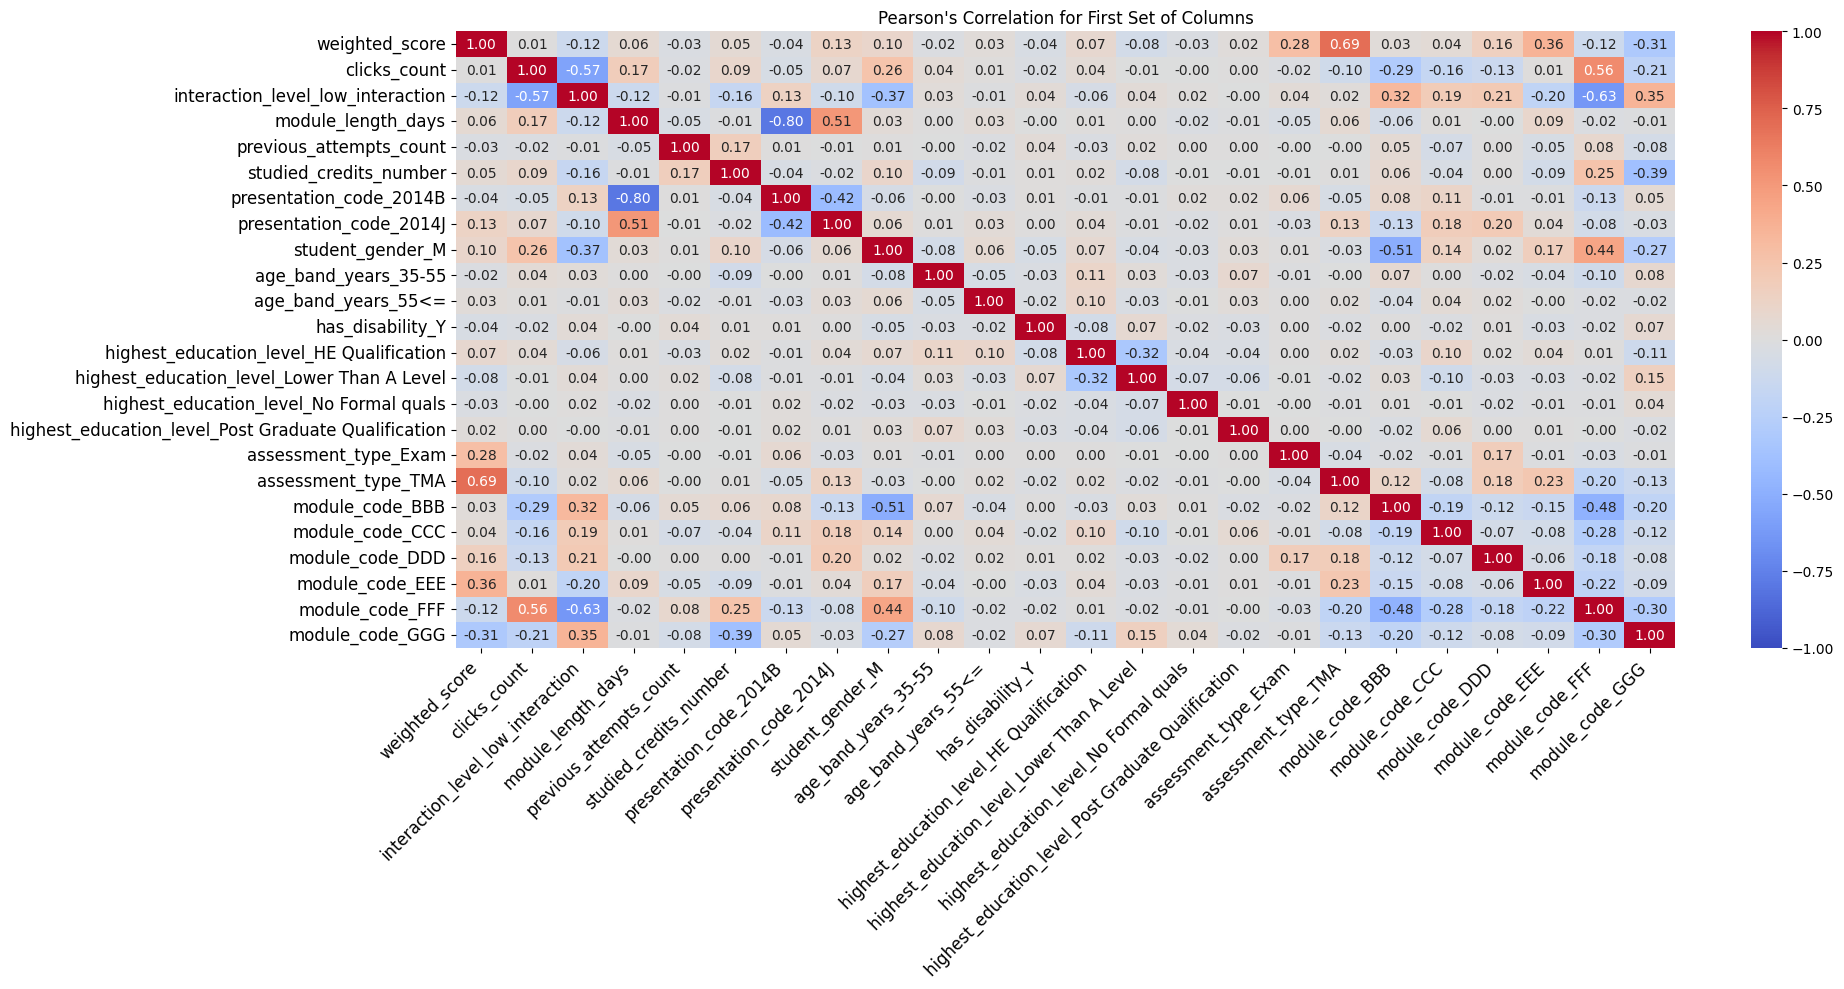

In [34]:
# Define the set of columns to analyze
set1_columns = ['weighted_score','clicks_count', 'interaction_level_low_interaction', 'module_length_days', 
                'previous_attempts_count', 'studied_credits_number', 'presentation_code_2014B', 'presentation_code_2014J', 
                'student_gender_M', 'age_band_years_35-55', 'age_band_years_55<=', 'has_disability_Y', 
                'highest_education_level_HE Qualification', 'highest_education_level_Lower Than A Level', 
                'highest_education_level_No Formal quals', 'highest_education_level_Post Graduate Qualification', 
                'assessment_type_Exam', 'assessment_type_TMA', 'module_code_BBB', 'module_code_CCC', 'module_code_DDD', 
                'module_code_EEE', 'module_code_FFF', 'module_code_GGG']

# Calculate the Pearson's correlation matrix for selected columns
p_oh_corr_matrix_1 = ohe_final_data[set1_columns].corr(numeric_only = True)

# Plot the results
plt.figure(figsize = (20, 10))  # Set figure size
sns.heatmap(p_oh_corr_matrix_1, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1)

# Titles and labels
plt.title("Pearson's Correlation for First Set of Columns")
# Rotate x-axis tick labels for readability
plt.xticks(rotation = 45, ha = 'right', fontsize = 12)  # Rotate and align
plt.yticks(fontsize = 12)  # Adjust y-axis tick font size

# Show the plot
plt.tight_layout()
plt.show()

**Features with good Correlation:**

**`assessment_type_TMA`**: This feature shows a moderate positive correlation (0.69) with weighted_score.

**`module_code_EEE`**: This feature exhibits a low positive correlation (0.36) with weighted_score.

**`module_code_GGG`**: This feature exhibits a low negative correlation (-0.31) with weighted_score.

rest of the features have negligible correlation

This code snippet computes and visualizes the Pearson correlation matrix for another set of columns (`set2_columns`) from the `ohe_final_data` DataFrame, using a similar approach as the previous one.

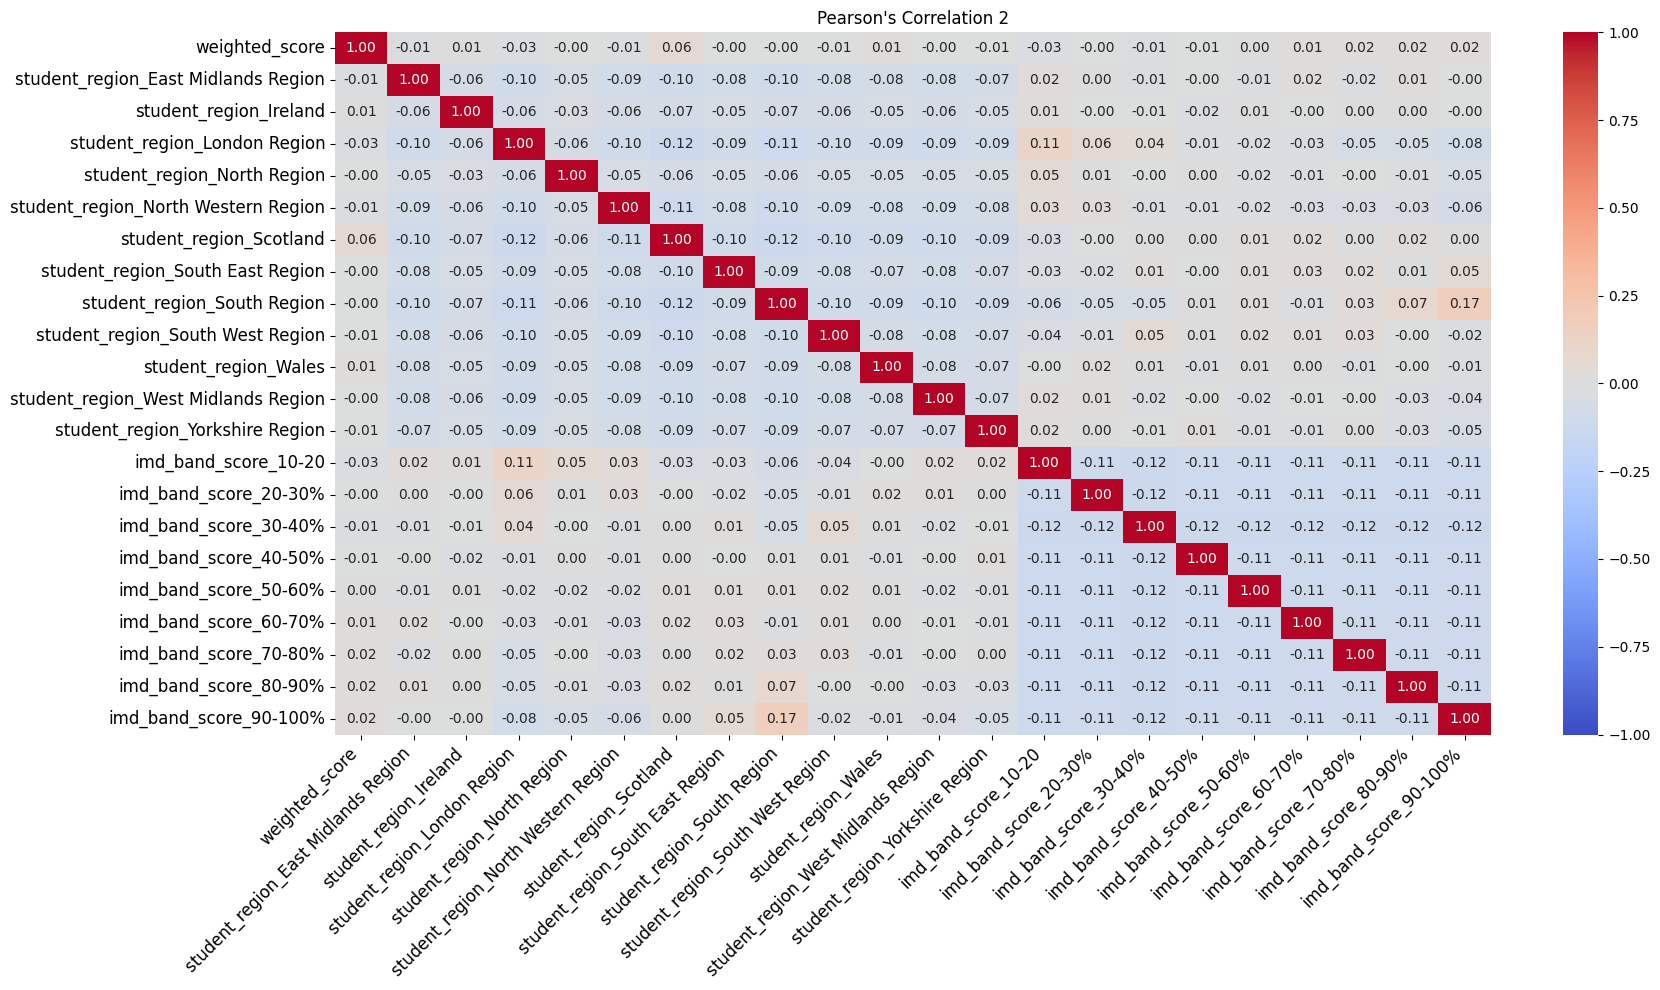

In [35]:
# Define another set of columns to analyze
set2_columns = ['weighted_score', 'student_region_East Midlands Region', 'student_region_Ireland', 'student_region_London Region', 
                'student_region_North Region', 'student_region_North Western Region', 'student_region_Scotland', 
                'student_region_South East Region', 'student_region_South Region', 'student_region_South West Region', 
                'student_region_Wales', 'student_region_West Midlands Region', 'student_region_Yorkshire Region', 
                'imd_band_score_10-20', 'imd_band_score_20-30%', 'imd_band_score_30-40%', 'imd_band_score_40-50%', 
                'imd_band_score_50-60%', 'imd_band_score_60-70%', 'imd_band_score_70-80%', 'imd_band_score_80-90%',
                'imd_band_score_90-100%']

# Calculate the Pearson's correlation matrix for the selected columns
p_oh_corr_matrix_2 = ohe_final_data[set2_columns].corr(numeric_only = True)

# Plot the results
plt.figure(figsize = (18, 10))  # Set figure size
sns.heatmap(p_oh_corr_matrix_2, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1)

# Titles and labels
plt.title("Pearson's Correlation 2")
# Rotate x-axis tick labels
plt.xticks(rotation = 45, ha = 'right', fontsize = 12)  # Rotate and align
plt.yticks(fontsize = 12)  # Adjust y-axis tick font size

# Show the plot
plt.tight_layout()
plt.show()

All the features have negligible correlation

### OLS Regression
This script uses Ordinary Least Squares (OLS) regression to model the relationship between `weighted_score` (dependent variable) and selected predictors (`clicks_count`, `assessment_type_Exam`, and `assessment_type_TMA`) from the dataset.

In [36]:
# Build the OLS model using the formula approach
model = sm.OLS.from_formula("weighted_score ~ clicks_count + assessment_type_TMA + module_code_EEE + module_code_GGG", data = ohe_final_data)

# Fit the model
result = model.fit()

# Display a slim summary of the model
result.summary(slim = True)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         weighted_score   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.570
No. Observations:              115839   F-statistic:                 3.842e+04
Covariance Type:            nonrobust   Prob (F-statistic):               0.00
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.7462      0.030     58.269      0.000       1.687       1.805
assessment_type_TMA[T.True]    10.8254      0.035    309.692      0.000      10.757      10.894
module_code_EEE[T.True]         7.2976      0.072    102.001      0.000       7.157       7.438
module_code_GGG[T.True]        -5.7082      0.055   -103.455      0.000      -5.816      -5.600
clicks_count                    0.0002   2.25e-05      9.846      0.000       0.000       0.000
===============================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.88e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- The R-squared value of **0.57** indicates that the model explains approximately **57%** of the variance in `weighted_score`
- All predictors are statistically significant (p-values < 0.001), indicating that they have a significant influence on `weighted_score`
- Other features are significantly less compared to `assessment_type_TMA` (**12.5089**). This suggests that students tend to score higher on TMAs

- The positive coefficient for `clicks_count` (0.0002) indicates that an slight increase in VLE usage ( very less impact) is associated with an increase in `weighted_score`

## 2. Linear Regression

This code applies Principal Component Analysis (PCA) to reduce the dimensionality of the dataset while retaining 95% of the variance. After transforming the features with PCA, a linear regression model is trained to predict the target variable, which is the `weighted_score`.

This process helps in handling high-dimensional data while focusing on the most informative components.

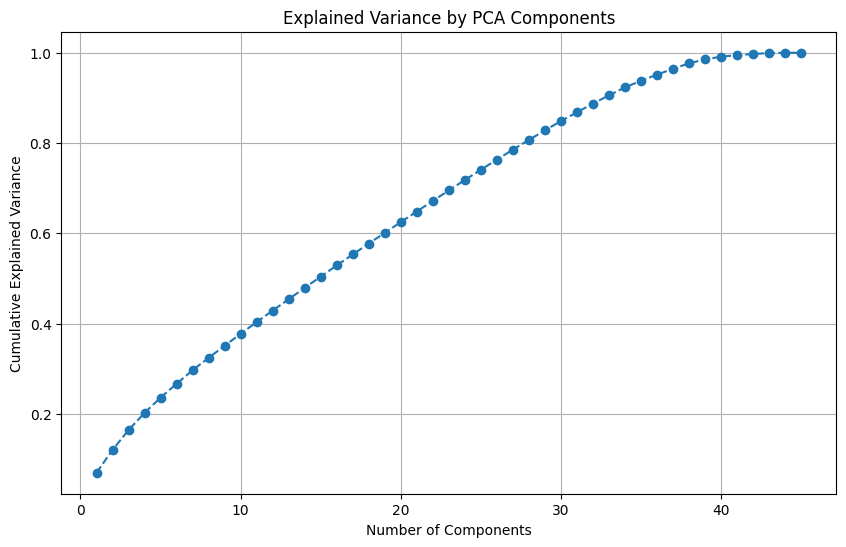

Optimal number of components: 36


In [37]:
# Separate features and target variable
X = ohe_final_data.drop(columns = ['weighted_score'])
y = ohe_final_data['weighted_score']

# Standardize the features
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# Determine the optimal number of components based on explained variance
pca = PCA()
pca.fit(X_standardized)

# Plot the cumulative explained variance to choose n_components
plt.figure(figsize = (10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

# Choose n_components (to retain 95% of the variance)
optimal_components = next(i for i, total in enumerate(pca.explained_variance_ratio_.cumsum()) if total >= 0.95) + 1
print(f"Optimal number of components: {optimal_components}")

# PCA with the chosen number of components
pca = PCA(n_components = optimal_components)
X_pca = pca.fit_transform(X_standardized)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size = 0.2, random_state = 42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

This code compares the actual and predicted values of the target variable (`weighted_score`) and visualizes their correlation using a heatmap. This code helps evaluate how well the model's predictions align with the actual values, providing a visual representation of model performance.

# Model Evaluation

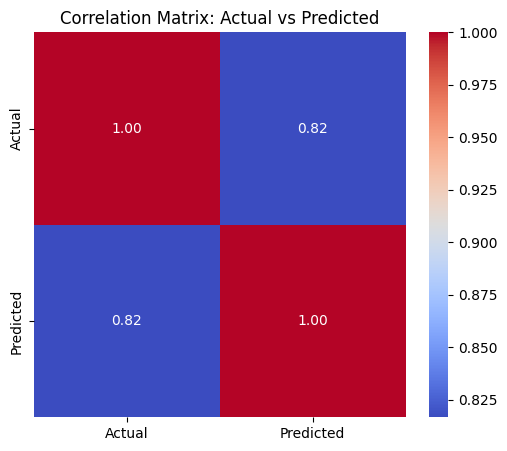

In [38]:
# Create a DataFrame for the actual and predicted values
predictions_comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Compute the correlation matrix between actual and predicted values
prediction_correlation = predictions_comparison_df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize = (6, 5))
sns.heatmap(prediction_correlation, annot = True, cmap = 'coolwarm', fmt = '.2f', cbar = True)
plt.title('Correlation Matrix: Actual vs Predicted')
plt.show()

**MAE (Mean Absolute Error)**:

Represents the average absolute difference between actual and predicted values.
Lower MAE indicates better model accuracy.


**R-squared (R²)**:

Reflects the proportion of the variance in the target variable explained by the predictors.
Values closer to 1 indicate a better fit.

In [39]:
# Finding the MAE, MSE, RMSE socre, r2
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R-squared: {r2_score(y_test, y_pred):.2f}')

MAE: 3.76
R-squared: 0.67


- On average, the model's predictions deviate by about **3.76** units from the actual weighted scores. Lower MAE values indicate better predictive accuracy.

-  **67%** of the target's variability is explained by the predictors. This is a reasonably high value, suggesting the model is effective at capturing the relationships between features and the target variable. However, 33% of the variance remains unexplained, indicating room for improvement.